In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [20]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('stud.csv')

In [4]:
X = df.drop(columns=['math score'], axis=1)
y = df['math score']

In [5]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [9]:
for col in X.columns:
    print(f"Attr: {col}, DType: {X[col].dtype}")

Attr: gender, DType: object
Attr: race/ethnicity, DType: object
Attr: parental level of education, DType: object
Attr: lunch, DType: object
Attr: test preparation course, DType: object
Attr: reading score, DType: int64
Attr: writing score, DType: int64


In [6]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [14]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", OneHotEncoder(), cat_features),
        ("StandardScaler", StandardScaler(), num_features)
    ]
)

In [15]:
X = preprocessor.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [22]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse =np.sqrt(mse)
    r2 = r2_score(true,predicted)
    return mae,rmse, r2

In [24]:
models = {
    "LinearRegression" : LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

In [32]:
models.items()

dict_items([('LinearRegression', LinearRegression()), ('Lasso', Lasso()), ('Ridge', Ridge()), ('K-Neighbors Regressor', KNeighborsRegressor()), ('Decision Tree', DecisionTreeRegressor()), ('Random Forest Regressor', RandomForestRegressor()), ('XGBRegressor', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None,

In [37]:
type(models['AdaBoost Regressor'])

sklearn.ensemble._weight_boosting.AdaBoostRegressor

In [38]:
model_list = []
r2_list = []

for model_key in models.keys():
    #Training
    model = models[model_key]
    model.fit(X_train, y_train)
    #Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    #Evaluation
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print(model_key)
    model_list.append(model_key)
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')
    
    

LinearRegression
Model performance for Training set
- Root Mean Squared Error: 5.3257
- Mean Absolute Error: 4.2695
- R2 Score: 0.8742
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.4212
- Mean Absolute Error: 4.2347
- R2 Score: 0.8792


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7079
- Mean Absolute Error: 4.5168
- R2 Score: 0.8555
------------------------

In [39]:
list(zip(model_list, r2_list))

[('LinearRegression', 0.8792262996178921),
 ('Lasso', 0.8253197323627852),
 ('Ridge', 0.8805931485028737),
 ('K-Neighbors Regressor', 0.7838129945787431),
 ('Decision Tree', 0.74264234498131),
 ('Random Forest Regressor', 0.8514648965015865),
 ('XGBRegressor', 0.8277965653186071),
 ('CatBoosting Regressor', 0.8516318920747058),
 ('AdaBoost Regressor', 0.846827123421616)]

In [51]:
list_scores = [[mn,r2_score] for mn, r2_score in zip(model_list, r2_list)]
list_scores

[['LinearRegression', 0.8792262996178921],
 ['Lasso', 0.8253197323627852],
 ['Ridge', 0.8805931485028737],
 ['K-Neighbors Regressor', 0.7838129945787431],
 ['Decision Tree', 0.74264234498131],
 ['Random Forest Regressor', 0.8514648965015865],
 ['XGBRegressor', 0.8277965653186071],
 ['CatBoosting Regressor', 0.8516318920747058],
 ['AdaBoost Regressor', 0.846827123421616]]

In [53]:
pd.DataFrame(data=list_scores, columns=['Model Name', 'R2 Score']).sort_values(by = ['R2 Score'], ascending=False)

,Model Name,R2 Score
2,Ridge,0.880593
0,LinearRegression,0.879226
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.851465
8,AdaBoost Regressor,0.846827
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.742642


In [61]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred) * 100
print(f"Accuracy of the model is {score:.2f}")


Accuracy of the model is 87.92


Text(0, 0.5, 'Predicted')

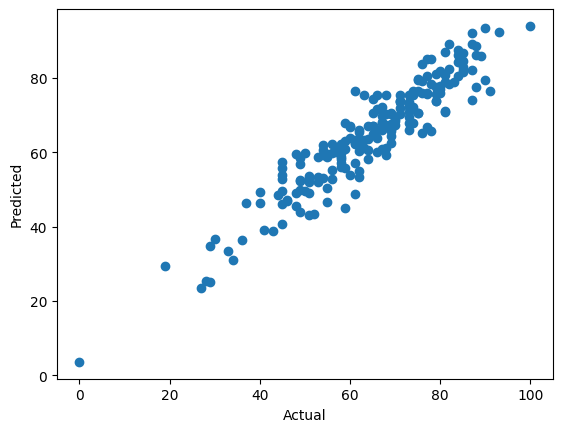

In [62]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math score'>

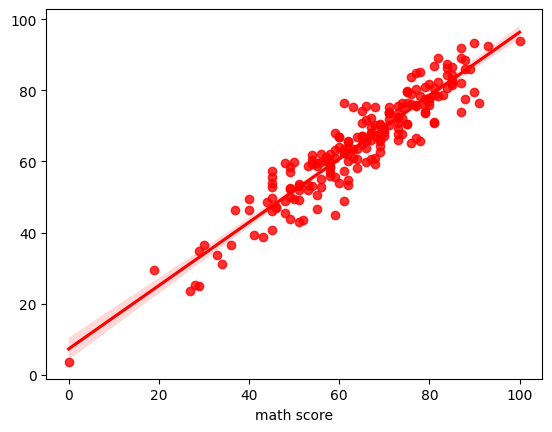

In [63]:
sns.regplot(x=y_test, y=y_pred, color='red')

In [70]:
pred_df = pd.DataFrame({'Actual Value' : y_test, 'Predicted Value' : y_pred, 'Difference' : y_test - y_pred , 'Difference Absolute': abs(y_test - y_pred)} ).sort_values(by=['Difference Absolute'], ascending=False)
pred_df

,Actual Value,Predicted Value,Difference,Difference Absolute
158,61,76.406250,-15.406250,15.406250
521,91,76.546875,14.453125,14.453125
265,59,44.890625,14.109375,14.109375
859,87,73.917969,13.082031,13.082031
199,78,65.695312,12.304688,12.304688
...,...,...,...,...
351,66,65.855469,0.144531,0.144531
259,65,64.863281,0.136719,0.136719
590,58,58.066406,-0.066406,0.066406
86,76,76.050781,-0.050781,0.050781
